# Model Evaluation

## Explainable Hybrid Deep Learning Framework for Multi-Class Dementia Detection using Brain MRI Images

### Objectives

- Load the trained EfficientNetV2 model
- Evaluate on the test dataset
- Measure test accuracy and loss
- Generate predictions
- Compute classification metrics
- Visualize model performance
- Analyze misclassified images

In [3]:
from pathlib import Path

import tensorflow as tf

from src.config.model_config import MODEL_SAVE_PATH
from src.dataset.loader import (
    create_dataloaders,
    INDEX_TO_LABEL,
)
from src.evaluation.metrics import compute_metrics
from src.evaluation.visualization import (
    plot_confusion_matrix,
    plot_prediction_distribution,
    plot_misclassified_images,
)

In [8]:
from pathlib import Path

metrics_path = Path.cwd().parent / "outputs" / "evaluation" / "metrics.json"

print(metrics_path)
print(metrics_path.exists())

g:\Projects\DementiaDetection\outputs\evaluation\metrics.json
True


In [9]:
import json
from pathlib import Path

metrics_path = (
    Path.cwd().parent
    / "outputs"
    / "evaluation"
    / "metrics.json"
)

with open(metrics_path, "r", encoding="utf-8") as file:
    metrics = json.load(file)

metrics

{'MildDemented': {'precision': 0.6054530874097834,
  'recall': 0.755,
  'f1-score': 0.6720071206052515,
  'support': 1000.0},
 'ModerateDemented': {'precision': 0.8883928571428571,
  'recall': 0.995,
  'f1-score': 0.9386792452830188,
  'support': 1000.0},
 'NonDemented': {'precision': 0.6185286103542235,
  'recall': 0.681,
  'f1-score': 0.6482627320323655,
  'support': 1000.0},
 'VeryMildDemented': {'precision': 0.631578947368421,
  'recall': 0.336,
  'f1-score': 0.4386422976501306,
  'support': 1000.0},
 'accuracy': 0.69175,
 'macro avg': {'precision': 0.6859883755688212,
  'recall': 0.69175,
  'f1-score': 0.6743978488926915,
  'support': 4000.0},
 'weighted avg': {'precision': 0.6859883755688213,
  'recall': 0.69175,
  'f1-score': 0.6743978488926916,
  'support': 4000.0},
 'test_loss': 0.7628697752952576}

In [10]:
print(f"Test Loss     : {metrics['test_loss']:.4f}")
print(f"Test Accuracy : {metrics['accuracy']:.4f}")

Test Loss     : 0.7629
Test Accuracy : 0.6917


In [11]:
import pandas as pd

report_df = pd.DataFrame(metrics).transpose()
report_df

,precision,recall,f1-score,support
MildDemented,0.605453,0.75500,0.672007,1000.00000
ModerateDemented,0.888393,0.99500,0.938679,1000.00000
NonDemented,0.618529,0.68100,0.648263,1000.00000
VeryMildDemented,0.631579,0.33600,0.438642,1000.00000
accuracy,0.691750,0.69175,0.691750,0.69175
macro avg,0.685988,0.69175,0.674398,4000.00000
weighted avg,0.685988,0.69175,0.674398,4000.00000
test_loss,0.762870,0.76287,0.762870,0.76287


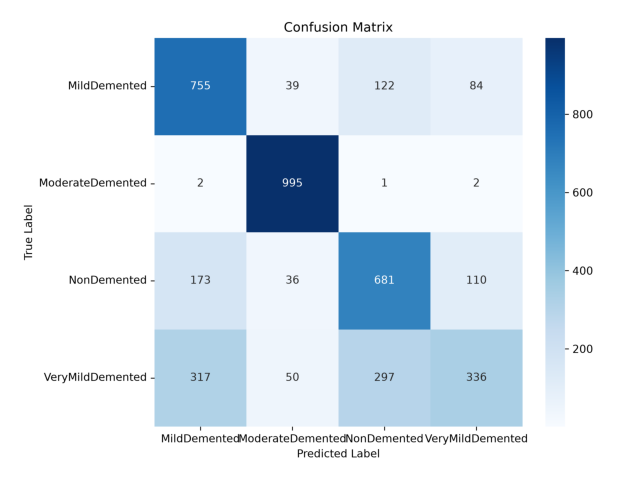

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(
    PROJECT_ROOT / "outputs" / "evaluation" / "confusion_matrix.png"
)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.show()